# Pair Classifier — Match vs. Ambiguous (LightGBM, **v4**)

**Entity resolution / ambiguity detection — non-matches folded in.** v4 is v3 with **one change**:
instead of *filtering out* the confident non-match pairs, we **keep them and label them `1`
("ambiguous")** alongside the genuinely ambiguous pairs. The model now sees the whole candidate
pool and learns a single boundary: **confident match (`0`)** vs **not a confident match (`1`)**,
where class `1` = *ambiguous ∪ confident non-match*. Positive = *"do **not** confidently auto-merge
this pair"*.

| | population | target 0 | target 1 |
|---|---|---|---|
| `_ambiguous_v3` | plausible only (match ∪ ambiguous) | confident match | ambiguous |
| **v4 (this notebook)** | **whole dataset** | **confident match** | **ambiguous ∪ confident non-match** |

**Rationale.** At serve time the Stage-4.5 ML matcher maps *high* score → `auto_merge`. v3 only ever
saw match-vs-ambiguous pairs, so a stray confident non-match that leaks past the FS gate is out of
distribution. v4 puts non-matches on the *same side of the boundary as ambiguous* (both = "don't
auto-merge"), which should make the confident-match decision more robust to gate leakage.

**Everything else is held identical to v3** so metric changes are attributable to the target/
population change alone: the same 12 v3 features (§5), the same LightGBM config (§7), the same random
stratified 60/20/20 split and `RANDOM_STATE`. The serving contract is unchanged — `1 - predict_proba[:, 1]`
is still `P(confident match)`.

> Standalone training/evaluation notebook — not wired into `src/pipeline.py`.

## 1. Setup & configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import jellyfish

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42

In [3]:
from pathlib import Path

def _find_service_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / 'data').is_dir() and (d / 'src').is_dir():
            return d
    raise FileNotFoundError("could not locate empi-service/ (no ancestor has data/ + src/)")

SERVICE_ROOT = _find_service_root(Path.cwd())
DATA_DIR = SERVICE_ROOT / 'data'

GOLD_LABELS_PATH = DATA_DIR / 'gold_labels' / 'final_gold_labels_v1_2026_07_05.csv'
CLEANED_PATH = DATA_DIR / 'processed' / 'MDM_Population_cleaned_v6_2026_06_25.parquet'

print('service root :', SERVICE_ROOT)
print('gold labels  :', GOLD_LABELS_PATH, '-> exists:', GOLD_LABELS_PATH.exists())
print('cleaned data :', CLEANED_PATH, '-> exists:', CLEANED_PATH.exists())

service root : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service
gold labels  : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\gold_labels\final_gold_labels_v1_2026_07_05.csv -> exists: True
cleaned data : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\processed\MDM_Population_cleaned_v6_2026_06_25.parquet -> exists: True


## 2. Data ingestion
Identical to v1/v2/v3. `dtype=str` on PATIDs preserves the leading-zeros invariant.

In [4]:
gold = pd.read_csv(GOLD_LABELS_PATH, dtype={'PATID_A': str, 'PATID_B': str})


def _to_bool(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s
    return s.astype(str).str.strip().str.lower().map(
        {'true': True, '1': True, '1.0': True, 'false': False, '0': False, '0.0': False})


gold['final_gold_label'] = _to_bool(gold['final_gold_label']).fillna(False).astype(bool)
gold['ambiguous_pair'] = _to_bool(gold['ambiguous_pair']).fillna(False).astype(bool)

print('gold labels shape :', gold.shape)
print('\nfinal_gold_label x ambiguous_pair (counts):')
print(pd.crosstab(gold['final_gold_label'], gold['ambiguous_pair']))

gold labels shape : (204805, 4)

final_gold_label x ambiguous_pair (counts):
ambiguous_pair     False  True 
final_gold_label               
False             142195     73
True               34560  27977


In [5]:
ATTRIBUTE_COLS = [
    'FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean',
    'SSN_clean', 'last_4_SSN', 'Email_clean', 'ZipCD_clean_base',
    'AddressLine1_clean', 'SexAtBirthDSC_clean', 'Phones_set',
]
cleaned = pd.read_parquet(CLEANED_PATH)
keep = ['PATID'] + [c for c in ATTRIBUTE_COLS if c in cleaned.columns]
cleaned = cleaned[keep].copy()
cleaned['PATID'] = cleaned['PATID'].astype(str)
cleaned = cleaned.drop_duplicates(subset='PATID', keep='first').set_index('PATID')
print('cleaned records shape:', cleaned.shape)
print('columns available    :', list(cleaned.columns))

cleaned records shape: (163364, 11)
columns available    : ['FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean', 'SSN_clean', 'last_4_SSN', 'Email_clean', 'ZipCD_clean_base', 'AddressLine1_clean', 'SexAtBirthDSC_clean', 'Phones_set']


In [6]:
a = cleaned.add_suffix('_A').reindex(gold['PATID_A'].values).reset_index(drop=True)
b = cleaned.add_suffix('_B').reindex(gold['PATID_B'].values).reset_index(drop=True)
pairs = pd.concat([gold.reset_index(drop=True), a, b], axis=1)

n_unmatched = (~gold['PATID_A'].isin(cleaned.index) | ~gold['PATID_B'].isin(cleaned.index)).sum()
print(f'pairs with a PATID not found in cleaned data: {n_unmatched} / {len(pairs)}')
print('joined pairs shape:', pairs.shape)

pairs with a PATID not found in cleaned data: 0 / 204805
joined pairs shape: (204805, 26)


## 3. Target definition (no population filter — v4 change)
**No filtering** — the whole candidate pool is used. Target: `0` = **confident match**
(`final_gold_label` AND NOT `ambiguous_pair`); `1` = **everything else** = *ambiguous ∪ confident
non-match*. This is the only change from v3, which dropped the confident non-matches; here they join
the ambiguous pairs in class `1`.

In [7]:
confident_match = pairs['final_gold_label'] & ~pairs['ambiguous_pair']
pairs['target_ambiguous'] = (~confident_match).astype(int)

print('target distribution (0=confident match, 1=ambiguous ∪ confident non-match):')
print(pairs['target_ambiguous'].value_counts())
print(f"\npositive rate (class 1): {pairs['target_ambiguous'].mean():.3f}")
print('\nbreakdown of the positive class (target=1):')
print(f"  ambiguous          (ambiguous_pair)               : {int(pairs['ambiguous_pair'].sum())}")
print(f"  confident non-match(~final_gold_label & ~ambiguous): {int((~pairs['final_gold_label'] & ~pairs['ambiguous_pair']).sum())}")

target distribution (0=confident match, 1=ambiguous ∪ confident non-match):
target_ambiguous
1    170245
0     34560
Name: count, dtype: int64

positive rate (class 1): 0.831

breakdown of the positive class (target=1):
  ambiguous          (ambiguous_pair)               : 28050
  confident non-match(~final_gold_label & ~ambiguous): 142195


## 4. Field selection
Same 8-field roster as v3. Drives both the **internal** `cmp_all` comparison (used for the
aggregate-free subgroup rule + ablation) and the v3 similarity features.

In [8]:
AVAILABLE_FIELDS = {
    'first_name':  'FirstNM_clean',
    'last_name':   'LastNM_clean',
    'middle_name': 'MiddleNM_clean',
    'birth_date':  'BirthDT_clean',
    'email':       'Email_clean',
    'ssn':         'SSN_clean',
    'address1':    'AddressLine1_clean',
    'phones':      'Phones_set',
}
SET_FIELDS = {'phones'}
SELECTED_FIELDS = ['first_name', 'last_name', 'middle_name', 'birth_date',
                   'email', 'ssn', 'address1', 'phones']
assert set(SELECTED_FIELDS) <= set(AVAILABLE_FIELDS)
print('fields:', SELECTED_FIELDS)

fields: ['first_name', 'last_name', 'middle_name', 'birth_date', 'email', 'ssn', 'address1', 'phones']


## 5. Feature engineering

Identical to v3. All features are continuous **except** `cmp_street_num`, `sound_first`,
`sound_last` (3-level categoricals). Missing on either side → `NaN`, handled natively by LightGBM.

| Feature | Type | Definition |
|---|---|---|
| `sim_jw_first` / `sim_jw_last` / `sim_jw_middle` | num | Jaro-Winkler on the name |
| `sound_first` / `sound_last` | cat | Metaphone code match (sound-alike) |
| `sim_lev_email` | num | normalized Levenshtein on email |
| `sim_lev_address1` | num | normalized Levenshtein on address line 1 |
| `addr_token_jaccard` | num | token overlap (Jaccard) of the address |
| `cmp_street_num` | cat | first numeric token of the address, matched exactly |
| `ssn_digit_frac` | num | fraction of position-wise matching SSN digits |
| `sim_dob` | num | normalized Levenshtein on the `YYYYMMDD` birth-date string |
| `sim_phones` | num | best (max) Jaro-Winkler across all cross pairs of the two phone sets |

In [9]:
import ast, re

MISSING, SAME, DIFFERENT = 'missing', 'same', 'different'
COMPARE_LEVELS = [MISSING, SAME, DIFFERENT]
_num_re = re.compile(r'\d+')
_NA_TOKENS = {'nan', 'none', '<na>', 'nat', 'null'}


def _norm(x):
    """Value -> lowercased stripped str, or None for any missing kind
    (None / np.nan / pd.NA / NaT). pd.NA is NOT an np.isscalar, so we test via pd.isna()."""
    if isinstance(x, str):
        s = x.strip().lower()
        return s if s and s not in _NA_TOKENS else None
    if x is None:
        return None
    try:
        if pd.isna(x):
            return None
    except (TypeError, ValueError):
        pass
    s = str(x).strip().lower()
    return s if s and s not in _NA_TOKENS else None


def _norm_series(s: pd.Series) -> pd.Series:
    return s.astype(object).map(_norm)


def _parse_set(value) -> set:
    """Set-valued cell (phones) -> set of strings. Handles native array/list and legacy string."""
    if isinstance(value, (set, frozenset, list, tuple, np.ndarray)):
        return {str(p).strip() for p in value if str(p).strip()}
    if pd.isna(value) or not isinstance(value, str):
        return set()
    v = value.strip()
    if v in ('', 'nan', 'None', 'set()', '{}', '[]'):
        return set()
    try:
        parsed = ast.literal_eval(v)
        if isinstance(parsed, (set, list, tuple)):
            return {str(p).strip() for p in parsed if str(p).strip()}
    except (ValueError, SyntaxError, TypeError):
        pass
    cleaned = v.strip('{}[]').replace("'", '').replace('"', '')
    return {p.strip() for p in cleaned.split(',') if p.strip()}


def _jw(x, y):
    if not (isinstance(x, str) and isinstance(y, str)):
        return np.nan
    return jellyfish.jaro_winkler_similarity(x, y)


def _lev_sim(x, y):
    if not (isinstance(x, str) and isinstance(y, str)):
        return np.nan
    m = max(len(x), len(y))
    return 1.0 - jellyfish.levenshtein_distance(x, y) / m if m else np.nan

### 5.1 Internal per-field comparison (`cmp_all`)
Computed for all eight fields but **not** used as model features (per v3, the aggregates are
dropped). It feeds the section-9 subgroup rule and the ablation baseline only.

In [10]:
def compare_field(df: pd.DataFrame, name: str, col: str) -> pd.Categorical:
    if name in SET_FIELDS:
        a = df[f'{col}_A'].apply(_parse_set)
        b = df[f'{col}_B'].apply(_parse_set)
        missing = (a.map(len) == 0) | (b.map(len) == 0)
        same = pd.Series([bool(x & y) for x, y in zip(a, b)], index=df.index) & ~missing
    else:
        a = _norm_series(df[f'{col}_A'])
        b = _norm_series(df[f'{col}_B'])
        missing = a.isna() | b.isna()
        same = (a == b) & ~missing
    out = np.where(missing, MISSING, np.where(same, SAME, DIFFERENT))
    return pd.Categorical(out, categories=COMPARE_LEVELS)


cmp_all = pd.DataFrame(index=pairs.index)
for name in SELECTED_FIELDS:
    cmp_all[f'cmp_{name}'] = compare_field(pairs, name, AVAILABLE_FIELDS[name])
print('internal cmp_all columns:', list(cmp_all.columns))

internal cmp_all columns: ['cmp_first_name', 'cmp_last_name', 'cmp_middle_name', 'cmp_birth_date', 'cmp_email', 'cmp_ssn', 'cmp_address1', 'cmp_phones']


### 5.2 Model features

In [11]:
feat = pd.DataFrame(index=pairs.index)
cat_features, num_features = [], []


def sim_column(col, fn):
    a = _norm_series(pairs[f'{col}_A'])
    b = _norm_series(pairs[f'{col}_B'])
    return pd.Series([fn(x, y) for x, y in zip(a, b)], index=pairs.index, dtype='float')


# --- Names: Jaro-Winkler ---
for name in ['first_name', 'last_name', 'middle_name']:
    feat[f'sim_jw_{name.split("_")[0]}'] = sim_column(AVAILABLE_FIELDS[name], _jw)
num_features += ['sim_jw_first', 'sim_jw_last', 'sim_jw_middle']

# --- Email / address: normalized Levenshtein only ---
feat['sim_lev_email'] = sim_column('Email_clean', _lev_sim)
feat['sim_lev_address1'] = sim_column('AddressLine1_clean', _lev_sim)
num_features += ['sim_lev_email', 'sim_lev_address1']

In [12]:
# --- Names: phonetic (Metaphone) sound-alike match ---
def _metaphone(x):
    s = _norm(x)
    if not s:
        return None
    return jellyfish.metaphone(s) or None


def sound_cmp(col):
    a = pairs[f'{col}_A'].map(_metaphone)
    b = pairs[f'{col}_B'].map(_metaphone)
    missing = a.isna() | b.isna()
    same = (a == b) & ~missing
    return pd.Categorical(np.where(missing, MISSING, np.where(same, SAME, DIFFERENT)), categories=COMPARE_LEVELS)


feat['sound_first'] = sound_cmp('FirstNM_clean')
feat['sound_last'] = sound_cmp('LastNM_clean')
cat_features += ['sound_first', 'sound_last']

In [13]:
# --- Address: street number (first numeric token), matched exactly; + token Jaccard ---
def _street_num(x):
    s = _norm(x)
    if not s:
        return None
    m = _num_re.search(s)
    return m.group() if m else None


sn_a = pairs['AddressLine1_clean_A'].map(_street_num)
sn_b = pairs['AddressLine1_clean_B'].map(_street_num)
sn_missing = sn_a.isna() | sn_b.isna()
sn_same = (sn_a == sn_b) & ~sn_missing
feat['cmp_street_num'] = pd.Categorical(
    np.where(sn_missing, MISSING, np.where(sn_same, SAME, DIFFERENT)), categories=COMPARE_LEVELS)
cat_features.append('cmp_street_num')


def _tok_jaccard(x, y):
    x, y = _norm(x), _norm(y)
    if not x or not y:
        return np.nan
    sx, sy = set(x.split()), set(y.split())
    return len(sx & sy) / len(sx | sy) if sx and sy else np.nan


feat['addr_token_jaccard'] = pd.Series(
    [_tok_jaccard(x, y) for x, y in zip(pairs['AddressLine1_clean_A'], pairs['AddressLine1_clean_B'])],
    index=pairs.index, dtype='float')
num_features.append('addr_token_jaccard')

In [14]:
# --- SSN: fraction of position-wise matching digits (typo-tolerant). ---
def _ssn_frac(x, y):
    x, y = _norm(x), _norm(y)
    if not x or not y:
        return np.nan
    n = min(len(x), len(y))
    if n == 0:
        return np.nan
    return sum(1 for i in range(n) if x[i] == y[i]) / max(len(x), len(y))


feat['ssn_digit_frac'] = pd.Series(
    [_ssn_frac(x, y) for x, y in zip(pairs['SSN_clean_A'], pairs['SSN_clean_B'])],
    index=pairs.index, dtype='float')
num_features.append('ssn_digit_frac')

In [15]:
# --- DOB: typo-tolerant similarity on the YYYYMMDD digit string (normalized Levenshtein). ---
dob_a = pd.to_datetime(pairs['BirthDT_clean_A'], errors='coerce')
dob_b = pd.to_datetime(pairs['BirthDT_clean_B'], errors='coerce')
sa = dob_a.dt.strftime('%Y%m%d')   # NaT -> NaN
sb = dob_b.dt.strftime('%Y%m%d')
feat['sim_dob'] = pd.Series([_lev_sim(x, y) for x, y in zip(sa, sb)], index=pairs.index, dtype='float')
num_features.append('sim_dob')

In [16]:
# --- Phones: best (max) Jaro-Winkler across all cross pairs of the two phone sets. ---
#     = smallest JW distance. Exact shared number -> 1.0; a one-digit typo still scores high.
def _phones_best_jw(av, bv):
    A, B = _parse_set(av), _parse_set(bv)
    if not A or not B:
        return np.nan
    return max(jellyfish.jaro_winkler_similarity(x, y) for x in A for y in B)


feat['sim_phones'] = pd.Series(
    [_phones_best_jw(av, bv) for av, bv in zip(pairs['Phones_set_A'], pairs['Phones_set_B'])],
    index=pairs.index, dtype='float')
num_features.append('sim_phones')

In [17]:
# Finalize: categorical dtype for tree-native categoricals; assemble feature list.
for c in cat_features:
    feat[c] = feat[c].astype('category')

FEATURE_COLS = cat_features + num_features
print(f'{len(cat_features)} categorical + {len(num_features)} numeric = {len(FEATURE_COLS)} features')
print('\ncategorical:', cat_features)
print('numeric    :', num_features)
feat[FEATURE_COLS].head()

3 categorical + 9 numeric = 12 features

categorical: ['sound_first', 'sound_last', 'cmp_street_num']
numeric    : ['sim_jw_first', 'sim_jw_last', 'sim_jw_middle', 'sim_lev_email', 'sim_lev_address1', 'addr_token_jaccard', 'ssn_digit_frac', 'sim_dob', 'sim_phones']


,sound_first,sound_last,cmp_street_num,sim_jw_first,sim_jw_last,sim_jw_middle,sim_lev_email,sim_lev_address1,addr_token_jaccard,ssn_digit_frac,sim_dob,sim_phones
0,same,same,same,1.000000,1.0,NaN,NaN,1.000000,1.000000,NaN,1.0,1.000000
1,same,same,same,1.000000,1.0,NaN,0.464286,1.000000,1.000000,NaN,1.0,1.000000
2,same,same,same,0.971429,1.0,NaN,NaN,1.000000,1.000000,NaN,1.0,1.000000
3,same,same,different,1.000000,1.0,NaN,1.000000,0.285714,0.166667,1.0,1.0,1.000000
4,same,same,different,1.000000,1.0,NaN,NaN,0.476190,0.333333,NaN,1.0,0.622222


### 5.3 Feature ↔ target signal check

In [18]:
y_full = pairs['target_ambiguous']
rows = []
for c in num_features:
    rows.append({'feature': c,
                 'mean_match': feat.loc[y_full == 0, c].mean(),
                 'mean_class1': feat.loc[y_full == 1, c].mean(),
                 'pct_missing': feat[c].isna().mean()})
print('Numeric features — mean by class (0=confident match, 1=ambiguous ∪ non-match):')
display(pd.DataFrame(rows).round(3))

for c in cat_features:
    ct = pairs.groupby(feat[c].astype('object'), observed=True)['target_ambiguous'].mean().round(3)
    print(f'{c:16s} P(class1|outcome): ' + '  '.join(f'{k}={v}' for k, v in ct.items()))

Numeric features — mean by class (0=confident match, 1=ambiguous ∪ non-match):


,feature,mean_match,mean_class1,pct_missing
0,sim_jw_first,0.989,0.536,0.000
1,sim_jw_last,0.975,0.556,0.000
2,sim_jw_middle,0.916,0.205,0.972
3,sim_lev_email,0.872,0.612,0.948
4,sim_lev_address1,0.638,0.639,0.041
5,addr_token_jaccard,0.519,0.535,0.041
6,ssn_digit_frac,0.990,0.201,0.770
7,sim_dob,1.000,0.556,0.000
8,sim_phones,0.865,0.928,0.042


sound_first      P(class1|outcome): different=0.99  missing=1.0  same=0.494
sound_last       P(class1|outcome): different=0.975  missing=0.0  same=0.554
cmp_street_num   P(class1|outcome): different=0.838  missing=0.848  same=0.825


## 6. Train / validation / test split
Random stratified 60/20/20 on the target — identical mechanics to v3 (same `RANDOM_STATE`).

In [19]:
X = feat[FEATURE_COLS]
y = pairs['target_ambiguous'].astype(int)

idx = np.arange(len(X))
idx_trainval, idx_test = train_test_split(idx, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
idx_train, idx_val = train_test_split(idx_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y.iloc[idx_trainval])

X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
X_val,   y_val   = X.iloc[idx_val],   y.iloc[idx_val]
X_test,  y_test  = X.iloc[idx_test],  y.iloc[idx_test]

for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'{name:5s}: n={len(yy):6d}  class1={yy.sum():6d}  class1_rate={yy.mean():.3f}')

train: n=122883  class1=102147  class1_rate=0.831
val  : n= 40961  class1= 34049  class1_rate=0.831
test : n= 40961  class1= 34049  class1_rate=0.831


## 7. Model training
Same LightGBM configuration as v3 — only the target/population differs. `class_weight='balanced'`
handles the ~5:1 imbalance (class 1 now dominates because the non-matches joined it).

In [20]:
params = dict(
    objective='binary', n_estimators=1000, learning_rate=0.05, num_leaves=15,
    min_child_samples=20, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    reg_lambda=1.0, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

model = lgb.LGBMClassifier(**params)
model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)],
)
print('best iteration:', model.best_iteration_)
print('best val AUC  :', round(model.best_score_['valid_0']['auc'], 4))

best iteration: 464
best val AUC  : 0.9984


## 8. Model evaluation (full held-out test set)
Positive class = **class 1 (ambiguous ∪ non-match)**. Threshold favors recall of class 1 (missing a
not-confident-match — i.e. wrongly auto-merging — is the costly error).

In [21]:
DECISION_THRESHOLD = 0.3
proba_test = model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= DECISION_THRESHOLD).astype(int)

print('Classification report (full test):\n')
print(classification_report(y_test, pred_test, target_names=['confident match (0)', 'ambiguous ∪ non-match (1)'], digits=3))
print(f'ROC AUC : {roc_auc_score(y_test, proba_test):.4f}')
print(f'PR  AUC : {average_precision_score(y_test, proba_test):.4f}')

Classification report (full test):

                           precision    recall  f1-score   support

      confident match (0)      0.907     0.982     0.943      6912
ambiguous ∪ non-match (1)      0.996     0.980     0.988     34049

                 accuracy                          0.980     40961
                macro avg      0.952     0.981     0.965     40961
             weighted avg      0.981     0.980     0.980     40961

ROC AUC : 0.9984
PR  AUC : 0.9997


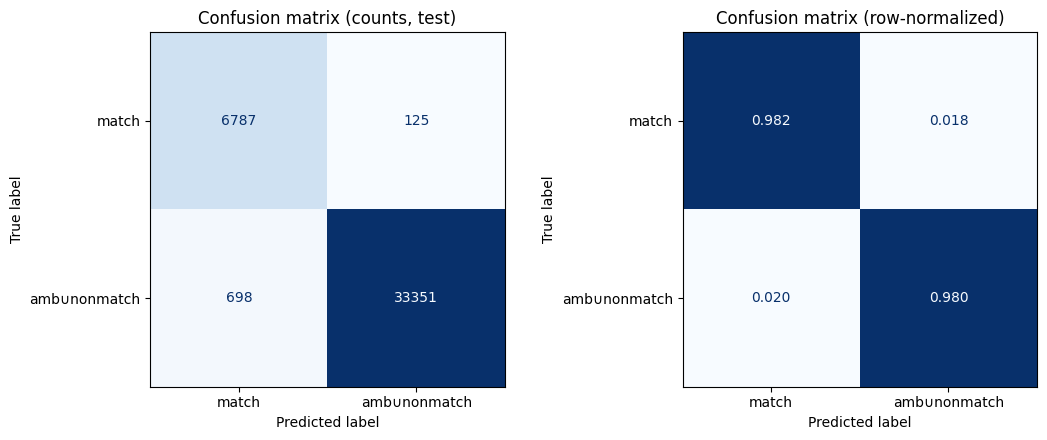

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['match', 'amb∪nonmatch']
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test), display_labels=labels).plot(ax=ax[0], colorbar=False, cmap='Blues')
ax[0].set_title('Confusion matrix (counts, test)')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test, normalize='true'), display_labels=labels).plot(ax=ax[1], colorbar=False, cmap='Blues', values_format='.3f')
ax[1].set_title('Confusion matrix (row-normalized)')
plt.tight_layout(); plt.show()

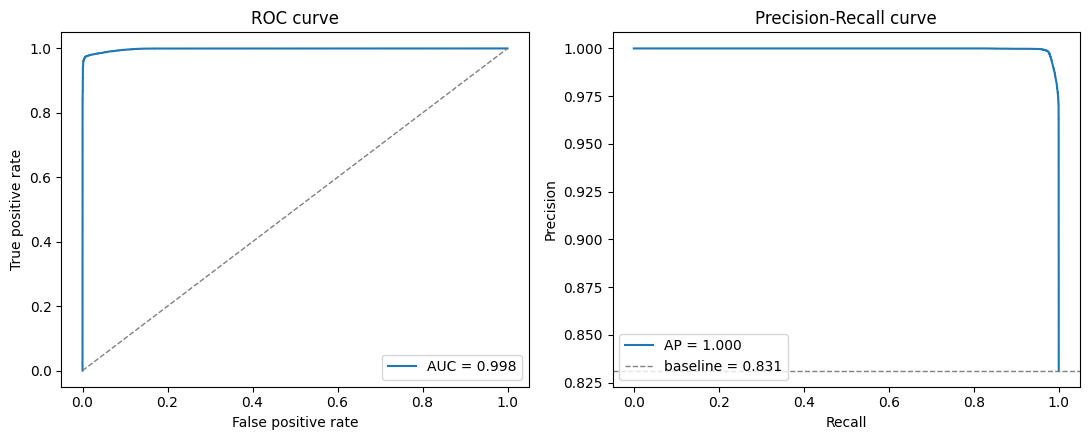

In [23]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, proba_test):.3f}')
ax[0].plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
ax[0].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curve'); ax[0].legend(loc='lower right')
ax[1].plot(rec, prec, label=f'AP = {average_precision_score(y_test, proba_test):.3f}')
ax[1].axhline(y_test.mean(), ls='--', color='grey', linewidth=1, label=f'baseline = {y_test.mean():.3f}')
ax[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall curve'); ax[1].legend(loc='lower left')
plt.tight_layout(); plt.show()

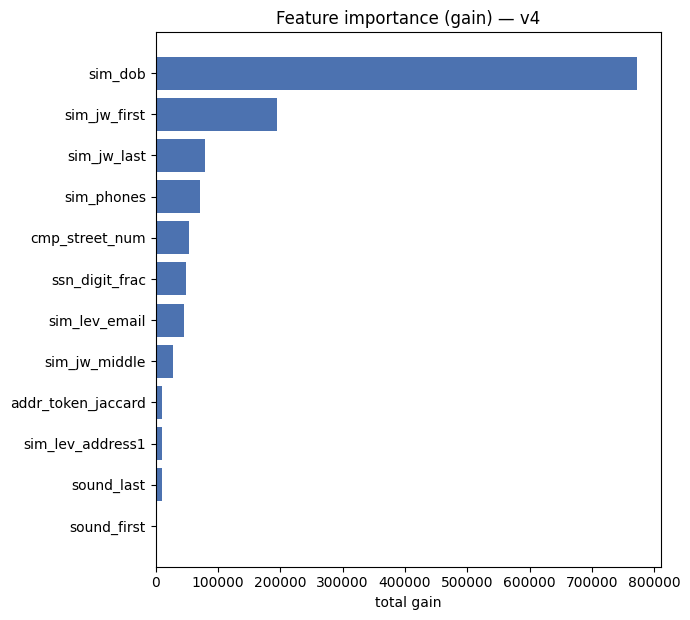

,feature,gain,split
10,sim_dob,772579.567523,291
3,sim_jw_first,194044.445495,1234
4,sim_jw_last,79496.810235,1195
11,sim_phones,71619.561077,814
2,cmp_street_num,53492.324564,189
9,ssn_digit_frac,48118.643446,435
6,sim_lev_email,45252.140344,495
5,sim_jw_middle,28325.253341,277
8,addr_token_jaccard,10461.676747,426
7,sim_lev_address1,10298.413198,891


In [24]:
imp = pd.DataFrame({'feature': model.feature_name_,
                    'gain': model.booster_.feature_importance(importance_type='gain'),
                    'split': model.booster_.feature_importance(importance_type='split')}).sort_values('gain', ascending=False)
fig, ax = plt.subplots(figsize=(7, 0.4 * len(imp) + 1.5))
ax.barh(imp['feature'][::-1], imp['gain'][::-1], color='#4C72B0')
ax.set(title='Feature importance (gain) — v4', xlabel='total gain')
plt.tight_layout(); plt.show()
imp

### 8.4 Confident-match (auto_merge) tier at the serving operating point
The pipeline serves this as a match scorer: `score = 1 - P(class 1) = P(confident match)`, and
`auto_merge` fires at `score >= 0.70`. This reports the precision/recall of that tier on held-out
data — the numbers the deploy gate reads and the ones directly comparable across v3/v4.

In [25]:
AUTO_MERGE_THRESHOLD = 0.70
score_test = 1.0 - proba_test                    # P(confident match)
y_match = (y_test.values == 0).astype(int)       # 1 = confident match (target == 0)
pred_auto = (score_test >= AUTO_MERGE_THRESHOLD).astype(int)

tp = int(((pred_auto == 1) & (y_match == 1)).sum())
fp = int(((pred_auto == 1) & (y_match == 0)).sum())
fn = int(((pred_auto == 0) & (y_match == 1)).sum())
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0
print(f'auto_merge (confident-match) tier @ score>={AUTO_MERGE_THRESHOLD}:')
print(f'  precision={precision:.4f}  recall={recall:.4f}  (tp={tp} fp={fp} fn={fn})')

auto_merge (confident-match) tier @ score>=0.7:
  precision=0.9067  recall=0.9819  (tp=6787 fp=698 fn=125)


### 8.5 Evaluation excluding confident non-matches (v3-comparable population)
Restrict the held-out test set to the **plausible** pairs only (`final_gold_label | ambiguous_pair`
— i.e. drop the confident non-matches v4 added). On this subset class `1` collapses back to *just
ambiguous*, so the confusion matrix and classification report are directly comparable to v3's §8:
the same match-vs-ambiguous decision, but from the model trained on the whole pool.

test set: 12464 plausible kept, 28497 confident non-matches excluded (of 40961)
ambiguous rate within plausible test subset: 0.445

Classification report (test, confident non-matches excluded), threshold=0.3:

                     precision    recall  f1-score   support

confident match (0)      0.946     0.982     0.964      6912
      ambiguous (1)      0.976     0.931     0.953      5552

           accuracy                          0.959     12464
          macro avg      0.961     0.956     0.958     12464
       weighted avg      0.960     0.959     0.959     12464

ROC AUC : 0.9938
PR  AUC : 0.9920


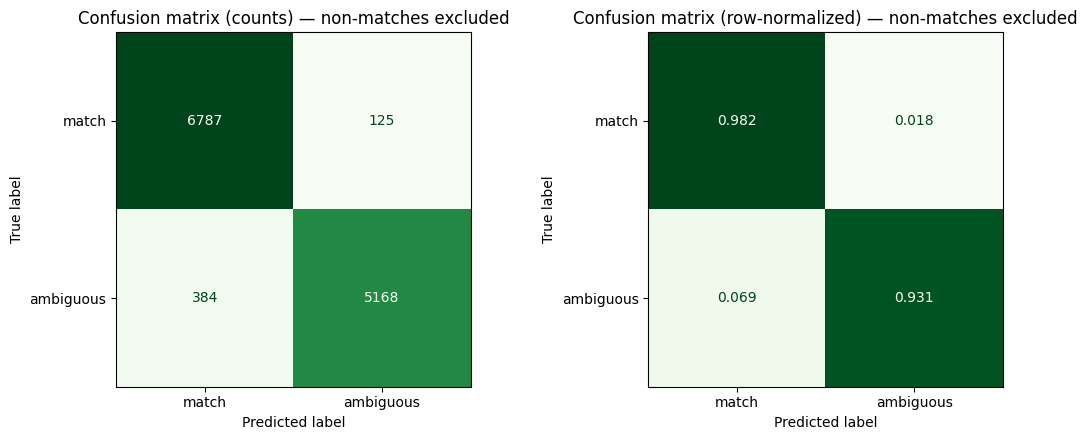

In [26]:
# Plausible = match ∪ ambiguous (i.e. NOT a confident non-match). Restrict the test set to it.
plausible_all = (pairs['final_gold_label'] | pairs['ambiguous_pair']).values
mask_test_plausible = plausible_all[idx_test]

y_test_p = y_test.values[mask_test_plausible]        # here 1 == ambiguous, 0 == confident match
pred_test_p = pred_test[mask_test_plausible]
proba_test_p = proba_test[mask_test_plausible]

n_excluded = int((~mask_test_plausible).sum())
print(f'test set: {mask_test_plausible.sum()} plausible kept, {n_excluded} confident non-matches excluded '
      f'(of {len(y_test)})')
print(f'ambiguous rate within plausible test subset: {y_test_p.mean():.3f}\n')

print(f'Classification report (test, confident non-matches excluded), threshold={DECISION_THRESHOLD}:\n')
print(classification_report(y_test_p, pred_test_p, target_names=['confident match (0)', 'ambiguous (1)'], digits=3))
print(f'ROC AUC : {roc_auc_score(y_test_p, proba_test_p):.4f}')
print(f'PR  AUC : {average_precision_score(y_test_p, proba_test_p):.4f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['match', 'ambiguous']
ConfusionMatrixDisplay(confusion_matrix(y_test_p, pred_test_p), display_labels=labels).plot(ax=ax[0], colorbar=False, cmap='Greens')
ax[0].set_title('Confusion matrix (counts) — non-matches excluded')
ConfusionMatrixDisplay(confusion_matrix(y_test_p, pred_test_p, normalize='true'), display_labels=labels).plot(ax=ax[1], colorbar=False, cmap='Greens', values_format='.3f')
ax[1].set_title('Confusion matrix (row-normalized) — non-matches excluded')
plt.tight_layout(); plt.show()

## 9. Deterministic-rule subgroup — dual evaluation

Same **label-independent feature rule** as v3 (no leakage): pairs that agree only on
first + last + DOB with everything else missing/disagreeing.

> `cmp_first_name == cmp_last_name == cmp_birth_date == same` **and** every other field `!= same`.

We report class-1 rate within the subgroup on the whole pool, then model metrics **both** on the
full test set and on the **residual** (subgroup removed).

In [27]:
AGREE_COLS = ['cmp_first_name', 'cmp_last_name', 'cmp_birth_date']
OTHER_COLS = [c for c in cmp_all.columns if c not in AGREE_COLS]

def subgroup_mask(index_like):
    sub = cmp_all.loc[index_like]
    three_agree = (sub[AGREE_COLS] == SAME).all(axis=1)
    rest_not_same = (sub[OTHER_COLS] != SAME).all(axis=1)   # different OR missing
    return (three_agree & rest_not_same).values

# Whole population.
mask_all = subgroup_mask(pairs.index)
n_sub = int(mask_all.sum())
rate_sub = pairs.loc[mask_all, 'target_ambiguous'].mean() if n_sub else float('nan')
print(f'subgroup size (full population): {n_sub} / {len(pairs)}  ({n_sub/len(pairs):.1%})')
print(f'  class-1 rate within subgroup: {rate_sub:.3f}   (overall: {pairs["target_ambiguous"].mean():.3f})')

subgroup size (full population): 24373 / 204805  (11.9%)
  class-1 rate within subgroup: 0.852   (overall: 0.831)


In [28]:
# Test-set split into subgroup vs residual.
test_index = pairs.index[idx_test]
mask_test_sub = subgroup_mask(test_index)
resid = ~mask_test_sub
print(f'test set: {mask_test_sub.sum()} subgroup, {resid.sum()} residual (of {len(y_test)})\n')


def report(mask, title):
    yy, pp, sc = y_test.values[mask], pred_test[mask], proba_test[mask]
    if len(yy) == 0 or len(np.unique(yy)) < 2:
        print(f'--- {title} (n={len(yy)}): too few / single-class, skipping AUC ---')
        if len(yy):
            print(f'    accuracy={ (yy==pp).mean():.3f}  class1_rate={yy.mean():.3f}')
        return
    print(f'--- {title} (n={len(yy)}, class1_rate={yy.mean():.3f}) ---')
    print(classification_report(yy, pp, target_names=['match', 'amb∪nonmatch'], digits=3, zero_division=0))
    print(f'    ROC AUC={roc_auc_score(yy, sc):.4f}   PR AUC={average_precision_score(yy, sc):.4f}\n')


report(np.ones(len(y_test), bool), 'FULL test')
report(resid, 'RESIDUAL test (subgroup removed)')
report(mask_test_sub, 'SUBGROUP only')

test set: 4819 subgroup, 36142 residual (of 40961)

--- FULL test (n=40961, class1_rate=0.831) ---
              precision    recall  f1-score   support

       match      0.907     0.982     0.943      6912
amb∪nonmatch      0.996     0.980     0.988     34049

    accuracy                          0.980     40961
   macro avg      0.952     0.981     0.965     40961
weighted avg      0.981     0.980     0.980     40961

    ROC AUC=0.9984   PR AUC=0.9997

--- RESIDUAL test (subgroup removed) (n=36142, class1_rate=0.829) ---
              precision    recall  f1-score   support

       match      0.897     0.982     0.938      6171
amb∪nonmatch      0.996     0.977     0.986     29971

    accuracy                          0.978     36142
   macro avg      0.947     0.979     0.962     36142
weighted avg      0.979     0.978     0.978     36142

    ROC AUC=0.9982   PR AUC=0.9996

--- SUBGROUP only (n=4819, class1_rate=0.846) ---
              precision    recall  f1-score   support



## 10. v1-vs-v3 feature ablation
Retrain the same config on only the eight v1 `cmp_<field>` categoricals (from `cmp_all`), same
split and target, and compare threshold-free metrics. The gap is the lift from v3's similarity
features on the **v4** target.

In [29]:
v1_cols = [f'cmp_{n}' for n in SELECTED_FIELDS]
Xv1 = cmp_all[v1_cols]
Xv1_train, Xv1_val, Xv1_test = Xv1.iloc[idx_train], Xv1.iloc[idx_val], Xv1.iloc[idx_test]

m_v1 = lgb.LGBMClassifier(**params)
m_v1.fit(Xv1_train, y_train, eval_set=[(Xv1_val, y_val)], eval_metric='auc',
         categorical_feature=v1_cols,
         callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)])
proba_v1 = m_v1.predict_proba(Xv1_test)[:, 1]

comparison = pd.DataFrame({
    'model': ['v1 (8 categoricals)', 'v3-features'],
    'n_features': [len(v1_cols), len(FEATURE_COLS)],
    'ROC_AUC': [roc_auc_score(y_test, proba_v1), roc_auc_score(y_test, proba_test)],
    'PR_AUC': [average_precision_score(y_test, proba_v1), average_precision_score(y_test, proba_test)],
}).round(4)
print('Held-out test comparison (same split, same config, v4 target):')
comparison

Held-out test comparison (same split, same config, v4 target):


,model,n_features,ROC_AUC,PR_AUC
0,v1 (8 categoricals),8,0.9875,0.9966
1,v3-features,12,0.9984,0.9997


## 11. Export the fitted model into the pipeline (Stage 4.5, serve-only)

Identical serving contract to v3: the pipeline treats `predict_proba(X)[:, 1]` as `P(class 1)` and
`MatchProbabilityAdapter` swaps it so column 1 = `P(confident match) = 1 - P(class 1)`; high score →
`auto_merge`. The only difference vs v3 is *what* class 1 means (now ambiguous ∪ non-match).

Writes `ml_model_<ts>.pkl` + `.meta.json` (held-out `metrics_auto_merge` at `score >= 0.70`, read by
the deploy gate) into `settings.ml_model_dir` and promotes via `registry.promote`.

> **This promotes into the served `ml_matcher` registry (`active.json`), same as v3** — running it
> swaps the served model. The deploy gate compares `metrics_auto_merge` against the current active
> model and may block promotion. Run this cell only when you intend to deploy v4.
>
> Requires the notebook to have been run top-to-bottom (`model`, `proba_test`, `y_test` must exist).

In [30]:
# import sys, json, datetime, joblib

# # Make `src` importable (SERVICE_ROOT is empi-service/, defined in section 1).
# if str(SERVICE_ROOT) not in sys.path:
#     sys.path.insert(0, str(SERVICE_ROOT))

# from src.config import settings
# from src.models.ml_matcher import registry
# from src.models.ml_matcher.lightgbm_v3 import MatchProbabilityAdapter

# # Match-scorer score on the held-out test set: P(confident match) = 1 - P(class 1).
# # 0.70 == the notebook operating point == EMPI_ML_AUTO_MERGE_THRESHOLD.
# AUTO_MERGE_THRESHOLD = 0.70
# score_test = 1.0 - proba_test                # proba_test = P(class 1), from section 8
# y_match = (y_test.values == 0).astype(int)   # 1 = confident match (target_ambiguous == 0)
# pred_auto = (score_test >= AUTO_MERGE_THRESHOLD).astype(int)

# tp = int(((pred_auto == 1) & (y_match == 1)).sum())
# fp = int(((pred_auto == 1) & (y_match == 0)).sum())
# fn = int(((pred_auto == 0) & (y_match == 1)).sum())
# precision = tp / (tp + fp) if (tp + fp) else 0.0
# recall = tp / (tp + fn) if (tp + fn) else 0.0

# ts = datetime.datetime.now(datetime.timezone.utc).strftime('%Y%m%dT%H%M%SZ')
# settings.ml_model_dir.mkdir(parents=True, exist_ok=True)
# artifact = settings.ml_model_dir / f'ml_model_{ts}.pkl'
# joblib.dump(MatchProbabilityAdapter(model), artifact)

# meta = {
#     'model_name': 'ml_matcher',
#     'model_file': artifact.name,
#     'created_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(),
#     'notes': ('LightGBM v4 classifier, serve-only. score = 1 - P(class 1); '
#               'class 1 = ambiguous ∪ confident non-match (v4 folds non-matches into the '
#               'ambiguous side). Trained on the whole pool, not the plausible-only subset.'),
#     'feature_cols': list(FEATURE_COLS),
#     'thresholds': {'auto_merge': AUTO_MERGE_THRESHOLD, 'review_floor': 0.40},
#     'test_metrics': {
#         'n_test': int(len(y_test)),
#         # metrics of the auto_merge (confident-match) tier — read by the deploy gate.
#         'metrics_auto_merge': {
#             'precision': round(precision, 4),
#             'recall': round(recall, 4),
#             'tp': tp, 'fp': fp, 'fn': fn,
#         },
#     },
# }
# registry.meta_path_for(artifact).write_text(json.dumps(meta, indent=2))
# reason = registry.promote(artifact, settings)   # writes active.json (first promotion always passes)

# print('artifact :', artifact)
# print('meta     :', registry.meta_path_for(artifact))
# print('active   :', settings.ml_model_dir / 'active.json')
# print('promoted :', reason)
# print(f'auto_merge tier @score>={AUTO_MERGE_THRESHOLD}:  P={precision:.3f}  R={recall:.3f}  (tp={tp} fp={fp} fn={fn})')

### Notes for the next iteration
- **v3 vs v4 head-to-head** — compare the §8.4 auto_merge precision/recall against v3's export
  metrics on the same held-out pairs; that is the decision-relevant comparison, not the raw AUC
  (the class balances differ, so AUC/PR-AUC are not directly comparable across v3 and v4).
- **Leakage-safe split** — PATID-grouped split for a stricter generalization estimate.
- **Threshold tuning** — set the `auto_merge` operating point from the tolerable false-merge rate.
- **Hyperparameter search** — the config is inherited from the balanced plausible-only task; retune
  on this imbalanced full-pool task.